In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Налаштування стилю
sns.set_theme(style="whitegrid")

# 1.1 Вибір та завантаження набору даних

df = pd.read_csv('bmw_global_sales_dataset.csv')
print("Перші 5 рядків оригінального датасету:")
display(df.head())

# 1.2 Базова підготовка даних

# Вибираємо числові колонки (1 цільова + 7 ознак)
# Нехай цільовою змінною (Y) буде 'units_sold' (кількість проданих авто)
num_cols = ['units_sold', 'price_usd', 'marketing_spend_usd', 'dealership_count',
            'fuel_price_usd', 'gdp_growth_percent', 'interest_rate_percent', 'competition_index']
df_num = df[num_cols].copy()

# Обробка пропусків (заповнюємо медіаною, якщо вони є)
df_num = df_num.fillna(df_num.median())

# Фільтрація аномалій (використовуємо метод міжквартильного розмаху - IQR)
print(f"\nКількість рядків ДО видалення аномалій: {len(df_num)}")
for col in df_num.columns:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Залишаємо лише ті значення, що лежать у нормальних межах
    df_num = df_num[(df_num[col] >= lower_bound) & (df_num[col] <= upper_bound)]

print(f"Кількість рядків ПІСЛЯ видалення аномалій: {len(df_num)}")

Перші 5 рядків оригінального датасету:


,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156



Кількість рядків ДО видалення аномалій: 1000
Кількість рядків ПІСЛЯ видалення аномалій: 1000


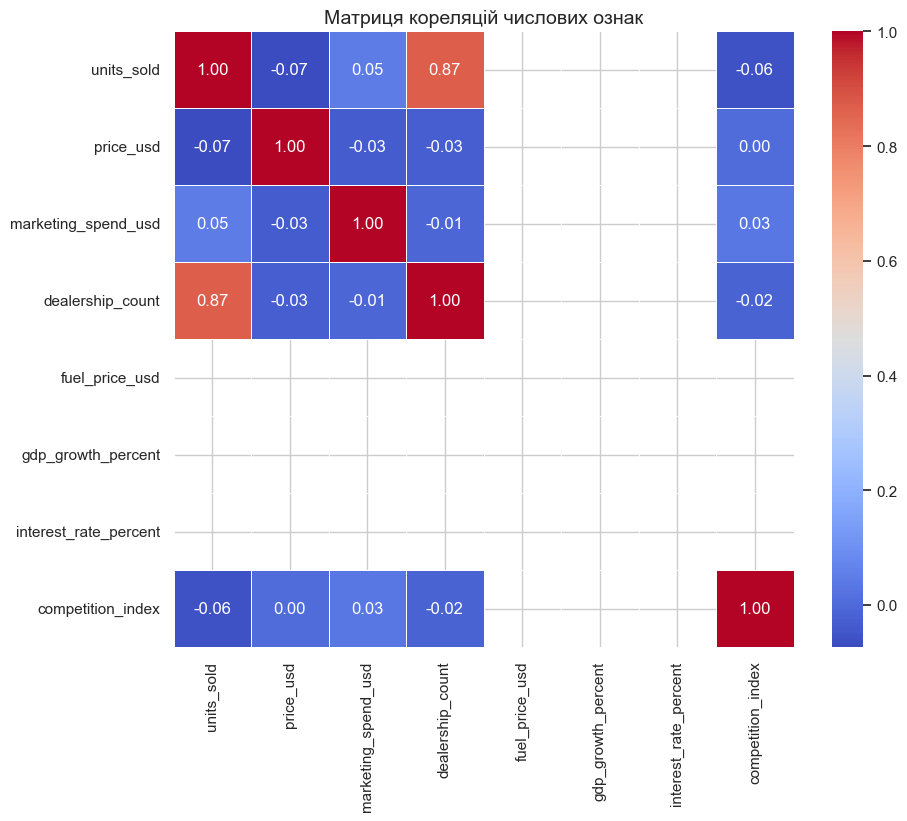


Кореляція ознак із цільовою змінною (units_sold):
dealership_count         0.868554
price_usd               -0.073839
competition_index       -0.059669
marketing_spend_usd      0.045648
fuel_price_usd                NaN
gdp_growth_percent            NaN
interest_rate_percent         NaN
Name: units_sold, dtype: float64

Розмір тренувальної вибірки: (800, 7)
Розмір тестової вибірки: (200, 7)


In [6]:
# 1.3 Знаходження залежностей

plt.figure(figsize=(10, 8))

# Обчислення кореляційної матриці
corr_matrix = df_num.corr()

# Візуалізація (Теплова карта)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляцій числових ознак', fontsize=14)
plt.show()

# Виведення ознак у порядку сили зв'язку з цільовою змінною (units_sold)
print("\nКореляція ознак із цільовою змінною (units_sold):")
target_corr = corr_matrix['units_sold'].drop('units_sold') # Відкидаємо саму себе
print(target_corr.sort_values(key=abs, ascending=False)) # Сортуємо за модулем

# "Сильна кореляція" зазвичай вважається такою, що по модулю > 0.7 або 0.8.
# Якщо між якимись ДВОМА ознаками (не цільовою) кореляція > 0.8, одну з них треба видалити,
# щоб уникнути мультиколінеарності. (Перевіримо це по тепловій карті).

# Поділ датасету на тренувальну (80%) та тестову (20%) вибірки
# Раціональний поділ: 80/20 або 70/30
X = df_num.drop('units_sold', axis=1) # Ознаки
y = df_num['units_sold']              # Цільова змінна

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРозмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Найбільш пов'язана ознака для графіка: dealership_count



,Модель / Вибірка,R^2 (Точність),MAE,MSLE,D^2 Absolute
0,Linear Regression (Train),0.759812,112.160648,0.088301,0.488336
1,Linear Regression (Test),0.763189,109.110469,0.096113,0.502324


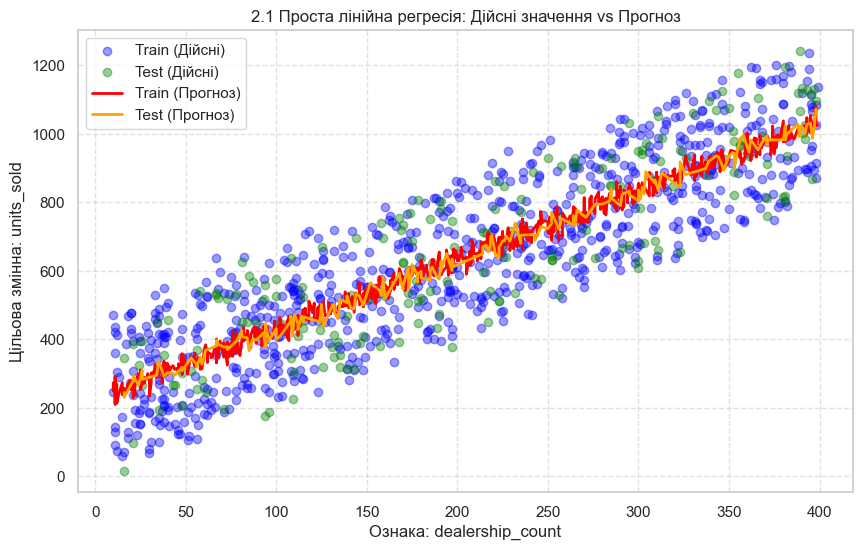

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_log_error, d2_absolute_error_score
import numpy as np
import pandas as pd

# Знаходимо ознаку з найбільшою кореляцією до цільової змінної (для візуалізації)
corr_target = df_num.corr()['units_sold'].drop('units_sold').abs()
best_feature = corr_target.idxmax()
print(f"Найбільш пов'язана ознака для графіка: {best_feature}\n")

# ЗАВДАННЯ 2.1: Проста лінійна регресія

# 1. Тренування моделі
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Функція для обчислення всіх необхідних метрик
def get_metrics(model, X, y, split_name):
    y_pred = model.predict(X)
    # MSLE (логарифмічна помилка) не працює з від'ємними прогнозами.
    # Тому обмежуємо найменше можливе значення маленьким числом (>0)
    y_pred_safe = np.clip(y_pred, 1e-5, None)

    return {
        'Модель / Вибірка': split_name,
        'R^2 (Точність)': model.score(X, y),
        'MAE': mean_absolute_error(y, y_pred),
        'MSLE': mean_squared_log_error(y, y_pred_safe),
        'D^2 Absolute': d2_absolute_error_score(y, y_pred)
    }

# Збираємо метрики у датафрейм
metrics_2_1 = pd.DataFrame([
    get_metrics(lr_model, X_train, y_train, 'Linear Regression (Train)'),
    get_metrics(lr_model, X_test, y_test, 'Linear Regression (Test)')
])
display(metrics_2_1)

# 3. Візуалізація
plt.figure(figsize=(10, 6))

# Сортуємо індекси осі X, щоб лінії прогнозів малювалися плавно, а не хаотично
train_idx = np.argsort(X_train[best_feature].values)
test_idx = np.argsort(X_test[best_feature].values)

# Точки дійсних значень (Scatter plot)
plt.scatter(X_train[best_feature], y_train, color='blue', alpha=0.4, label='Train (Дійсні)')
plt.scatter(X_test[best_feature], y_test, color='green', alpha=0.4, label='Test (Дійсні)')

# Лінії прогнозів (Line plot)
plt.plot(X_train[best_feature].values[train_idx], lr_model.predict(X_train)[train_idx],
         color='red', linewidth=2, label='Train (Прогноз)')
plt.plot(X_test[best_feature].values[test_idx], lr_model.predict(X_test)[test_idx],
         color='orange', linewidth=2, label='Test (Прогноз)')

plt.xlabel(f"Ознака: {best_feature}")
plt.ylabel('Цільова змінна: units_sold')
plt.title('2.1 Проста лінійна регресія: Дійсні значення vs Прогноз')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

,Модель / Вибірка,R^2 (Точність),MAE,MSLE,D^2 Absolute
0,Linear Reg Normal (Train),0.751772,112.928393,0.088860,0.484833
1,Linear Reg Normal (Test),0.751861,111.588010,0.092705,0.491023


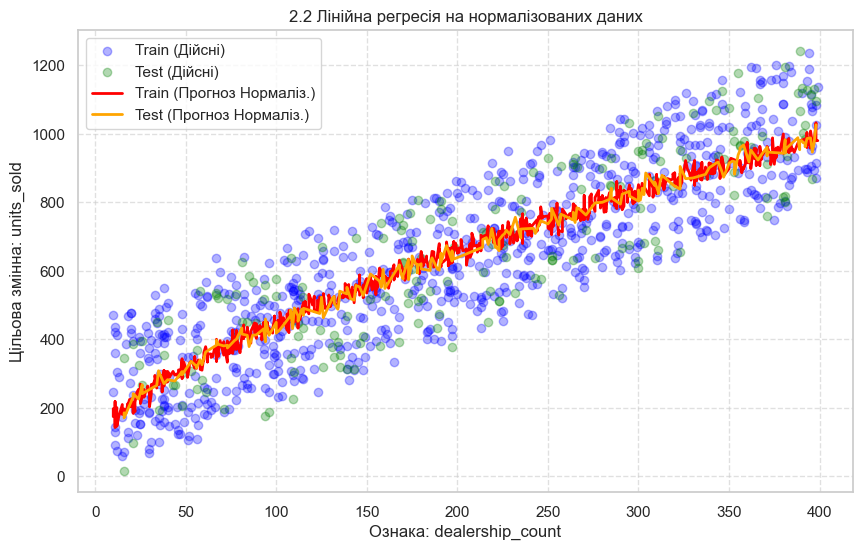

In [8]:
from sklearn.preprocessing import PowerTransformer

# ЗАВДАННЯ 2.2: Лінійна регресія з перетворенням змінних

# Крок 0.5. Перетворення усіх змінних (X) до нормального розподілу (метод yeo-johnson)
scaler = PowerTransformer(method='yeo-johnson')

X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_norm = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Крок 1. Тренування нової моделі на нормалізованих даних
lr_model_norm = LinearRegression()
lr_model_norm.fit(X_train_norm, y_train)

# Крок 2. Метрики
metrics_2_2 = pd.DataFrame([
    get_metrics(lr_model_norm, X_train_norm, y_train, 'Linear Reg Normal (Train)'),
    get_metrics(lr_model_norm, X_test_norm, y_test, 'Linear Reg Normal (Test)')
])
display(metrics_2_2)

# Крок 3. Візуалізація
plt.figure(figsize=(10, 6))

# Для графіка використовуємо оригінальну шкалу X, щоб графіки 2.1 і 2.2 можна було порівняти візуально
plt.scatter(X_train[best_feature], y_train, color='blue', alpha=0.3, label='Train (Дійсні)')
plt.scatter(X_test[best_feature], y_test, color='green', alpha=0.3, label='Test (Дійсні)')

# Але лінію прогнозу будуємо за допомогою моделі, натренованої на нормалізованих даних!
plt.plot(X_train[best_feature].values[train_idx], lr_model_norm.predict(X_train_norm)[train_idx],
         color='red', linewidth=2, label='Train (Прогноз Нормаліз.)')
plt.plot(X_test[best_feature].values[test_idx], lr_model_norm.predict(X_test_norm)[test_idx],
         color='orange', linewidth=2, label='Test (Прогноз Нормаліз.)')

plt.xlabel(f"Ознака: {best_feature}")
plt.ylabel('Цільова змінна: units_sold')
plt.title('2.2 Лінійна регресія на нормалізованих даних')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

,Модель / Вибірка,R^2 (Точність),MAE,MSLE,D^2 Absolute
0,Ridge (alpha=1.0) Train,0.759812,112.160563,0.088302,0.488336
1,Ridge (alpha=1.0) Test,0.763189,109.110359,0.096113,0.502325
2,Ridge (alpha=10.0) Train,0.759812,112.159806,0.088303,0.488340
3,Ridge (alpha=10.0) Test,0.763189,109.109372,0.096115,0.502329
4,Ridge (alpha=100.0) Train,0.759812,112.152636,0.088315,0.488372
5,Ridge (alpha=100.0) Test,0.763192,109.099851,0.096137,0.502373


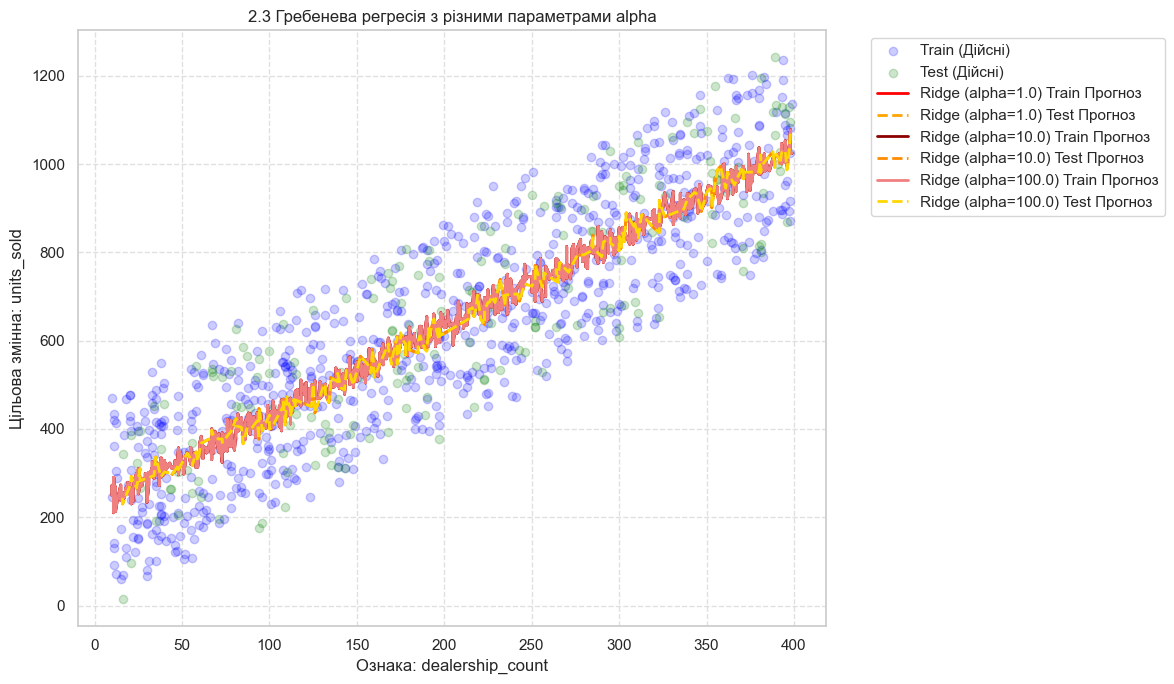

In [9]:
from sklearn.linear_model import Ridge

# ЗАВДАННЯ 2.3: Гребенева регресія (Ridge)

# Вибираємо власні значення alpha
alphas = [1.0, 10.0, 100.0] # 1.0 - це за замовчуванням
ridge_models = {}
metrics_2_3_list = []

plt.figure(figsize=(12, 7))

# Точки дійсних значень
plt.scatter(X_train[best_feature], y_train, color='blue', alpha=0.2, label='Train (Дійсні)')
plt.scatter(X_test[best_feature], y_test, color='green', alpha=0.2, label='Test (Дійсні)')

colors_train = ['red', 'darkred', 'lightcoral']
colors_test = ['orange', 'darkorange', 'gold']

# Тренуємо 3 моделі в циклі, збираємо метрики та малюємо лінії
for i, a in enumerate(alphas):
    model_name = f'Ridge (alpha={a})'

    # 1. Тренування
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_models[model_name] = ridge

    # 2. Метрики
    metrics_2_3_list.append(get_metrics(ridge, X_train, y_train, f'{model_name} Train'))
    metrics_2_3_list.append(get_metrics(ridge, X_test, y_test, f'{model_name} Test'))

    # 3. Лінії прогнозів
    plt.plot(X_train[best_feature].values[train_idx], ridge.predict(X_train)[train_idx],
             color=colors_train[i], linewidth=2, label=f'{model_name} Train Прогноз')
    plt.plot(X_test[best_feature].values[test_idx], ridge.predict(X_test)[test_idx],
             color=colors_test[i], linewidth=2, linestyle='--', label=f'{model_name} Test Прогноз')

# Зберігаємо метрики у датафрейм
metrics_2_3 = pd.DataFrame(metrics_2_3_list)
display(metrics_2_3)

plt.xlabel(f"Ознака: {best_feature}")
plt.ylabel('Цільова змінна: units_sold')
plt.title('2.3 Гребенева регресія з різними параметрами alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Легенда збоку, щоб не перекривала графік
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

,Модель / Вибірка,R^2 (Точність),MAE,MSLE,D^2 Absolute
0,Ridge Norm (alpha=1.0) Train,0.751771,112.931552,0.088864,0.484819
1,Ridge Norm (alpha=1.0) Test,0.751779,111.620927,0.092761,0.490873
2,Ridge Norm (alpha=10.0) Train,0.751658,112.976318,0.088964,0.484615
3,Ridge Norm (alpha=10.0) Test,0.750959,111.931807,0.093296,0.489455
4,Ridge Norm (alpha=100.0) Train,0.742537,114.302698,0.094045,0.478564
5,Ridge Norm (alpha=100.0) Test,0.736053,116.037401,0.100234,0.470729


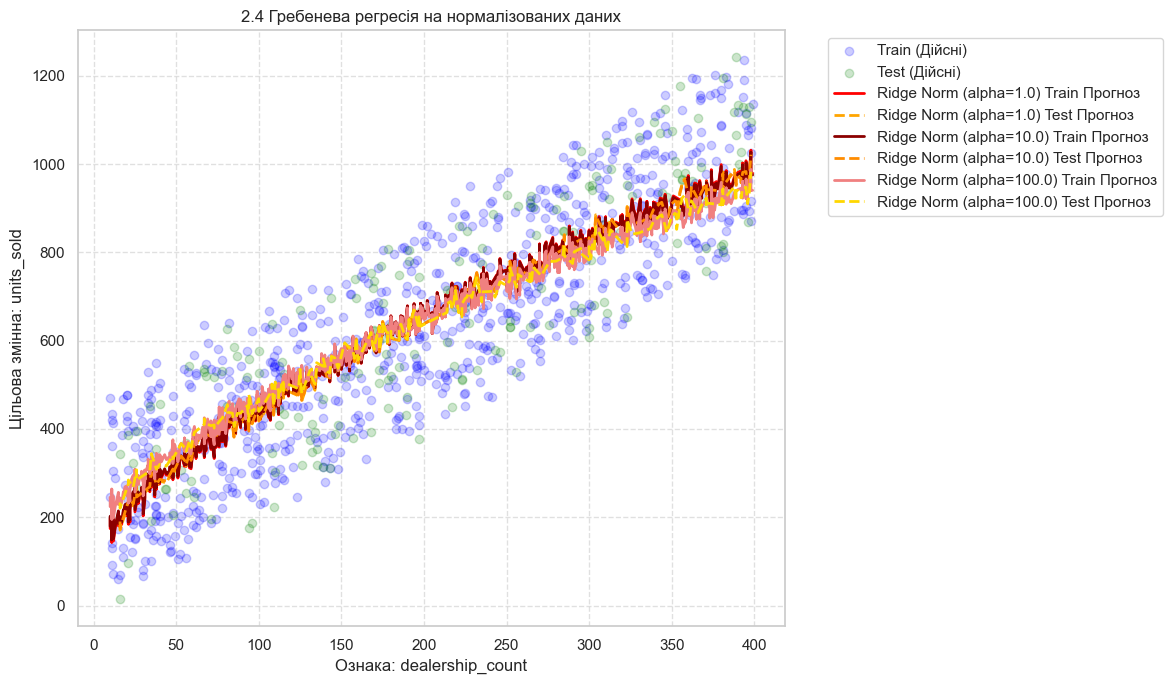

In [10]:
# ЗАВДАННЯ 2.4: Гребенева регресія з перетворенням змінних

ridge_norm_models = {}
metrics_2_4_list = []

plt.figure(figsize=(12, 7))

plt.scatter(X_train[best_feature], y_train, color='blue', alpha=0.2, label='Train (Дійсні)')
plt.scatter(X_test[best_feature], y_test, color='green', alpha=0.2, label='Test (Дійсні)')

for i, a in enumerate(alphas):
    model_name = f'Ridge Norm (alpha={a})'

    # 1. Тренування на нормалізованих даних
    ridge_norm = Ridge(alpha=a)
    ridge_norm.fit(X_train_norm, y_train)
    ridge_norm_models[model_name] = ridge_norm

    # 2. Метрики
    metrics_2_4_list.append(get_metrics(ridge_norm, X_train_norm, y_train, f'{model_name} Train'))
    metrics_2_4_list.append(get_metrics(ridge_norm, X_test_norm, y_test, f'{model_name} Test'))

    # 3. Лінії прогнозів (ось X беремо оригінальну для графіка, а передбачаємо на нормалізованій)
    plt.plot(X_train[best_feature].values[train_idx], ridge_norm.predict(X_train_norm)[train_idx],
             color=colors_train[i], linewidth=2, label=f'{model_name} Train Прогноз')
    plt.plot(X_test[best_feature].values[test_idx], ridge_norm.predict(X_test_norm)[test_idx],
             color=colors_test[i], linewidth=2, linestyle='--', label=f'{model_name} Test Прогноз')

metrics_2_4 = pd.DataFrame(metrics_2_4_list)
display(metrics_2_4)

plt.xlabel(f"Ознака: {best_feature}")
plt.ylabel('Цільова змінна: units_sold')
plt.title('2.4 Гребенева регресія на нормалізованих даних')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [11]:
# ЗАВДАННЯ 2.5: Сукупне порівняння метрик

# Об'єднуємо всі датафрейми з метриками
all_metrics = pd.concat([metrics_2_1, metrics_2_2, metrics_2_3, metrics_2_4], ignore_index=True)

# Робимо назву моделі індексом для зручності
all_metrics.set_index('Модель / Вибірка', inplace=True)

# Застосовуємо кольорову шкалу: червоний - менше, зелений - більше (cmap='RdYlGn')
# Jupyter Notebook вміє гарно відмальовувати стилізовані датафрейми за допомогою властивості .style
styled_metrics = all_metrics.style.background_gradient(cmap='RdYlGn') \
                            .format("{:.4f}") \
                            .set_caption("Сукупне порівняння метрик регресійних моделей")

# Виводимо фінальну кольорову таблицю
display(styled_metrics)

,R^2 (Точність),MAE,MSLE,D^2 Absolute
Модель / Вибірка,,,,
Linear Regression (Train),0.7598,112.1606,0.0883,0.4883
Linear Regression (Test),0.7632,109.1105,0.0961,0.5023
Linear Reg Normal (Train),0.7518,112.9284,0.0889,0.4848
Linear Reg Normal (Test),0.7519,111.5880,0.0927,0.4910
Ridge (alpha=1.0) Train,0.7598,112.1606,0.0883,0.4883
Ridge (alpha=1.0) Test,0.7632,109.1104,0.0961,0.5023
Ridge (alpha=10.0) Train,0.7598,112.1598,0.0883,0.4883
Ridge (alpha=10.0) Test,0.7632,109.1094,0.0961,0.5023
Ridge (alpha=100.0) Train,0.7598,112.1526,0.0883,0.4884
